## Spotify Decade Prediction System
### 1. Project Overview

In this project, we aim to build a machine learning model capable of predicting the release decade of a song based on its audio features.

We are utilizing a dataset obtained via the Spotify API, containing over 500,000 tracks. This dataset includes technical audio metrics (such as danceability, energy, and acousticness) but lacks lyrical content. Our goal is to determine if audio engineering and musical composition trends alone are sufficient to classify songs into their respective eras.

### 2. Data Loading and Initial Inspection

First, we will import the necessary libraries and load the raw dataset.

In [1]:
import sys
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

/Users/alejandrotreny/miniforge3/envs/my_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

In [ ]:
file_path = kagglehub.dataset_download(
    "yamaerenay/spotify-dataset-19212020-600k-tracks", 
    path="tracks.csv"
)

print(f"File saved to: {file_path}")
tracks = pd.read_csv(file_path)

print(f"Dataset successfully loaded! Shape: {tracks.shape}")

100%|██████████| 47.6M/47.6M [00:03<00:00, 14.8MB/s]

Extracting zip of tracks.csv...


File saved to: /Users/alejandrotreny/.cache/kagglehub/datasets/yamaerenay/spotify-dataset-19212020-600k-tracks/versions/1/tracks.csv
Dataset successfully loaded! Shape: (586672, 20)


,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


In [6]:
tracks.head()

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


### 3. Column Descriptions & Feature Selection

To interpret the model's results correctly, we must understand the technical definition and value range of each feature provided by the Spotify API.

#### A. Mood & rhythmic properties (0.0 to 1.0 scale)

These features are normalized probabilities or measurements between 0 and 1.

`danceability`

- Definition: Describes how suitable a track is for dancing based on a combination of musical elements including tempo, rhythm stability, beat strength, and overall regularity.
- Range: 0.0 (Least danceable) to 1.0 (Most danceable).

`energy`

- Definition: A perceptual measure of intensity and activity. Energetic tracks feel fast, loud, and noisy. Perceptual features contributing to this attribute include dynamic range, perceived loudness, timbre, onset rate, and general entropy.
- Range: 0.0 (Least energetic) to 1.0 (Most energetic).

`valence`

- Definition: A measure describing the musical "positiveness" conveyed by a track. Tracks with high valence sound more positive (e.g., happy, cheerful, euphoric), while tracks with low valence sound more negative (e.g., sad, depressed, angry).
- Range: 0.0 (Negative/Sad) to 1.0 (Positive/Happy).

`acousticness`

- Definition: A confidence measure of whether the track is acoustic (using non-electronic instruments). 
- Range: 0.0 (Not acoustic) to 1.0 (Acoustic).

`instrumentalness`

- Definition: Predicts whether a track contains no vocals. "Ooh" and "aah" sounds are treated as instrumental in this context. Rap or spoken word tracks are clearly "vocal".
- Range: 0.0 (Not instrumental) to 1.0 (Instrumental). Values above 0.5 are intended to represent instrumental tracks, but confidence is higher as the value approaches 1.0.

`speechiness`

- Definition: Detects the presence of spoken words in a track. The more exclusively speech-like the recording (e.g. talk show, audio book, poetry), the closer to 1.0 the attribute value.
- Range: 0.0 (Not speech) to 1.0 (Speech). Values above 0.66 describe tracks that are probably made entirely of spoken words. Values between 0.33 and 0.66 describe tracks that may contain both music and speech (e.g. rap music).

#### B. Technical Audio Properties

These features have physical units or specific categorical mappings.

`loudness`

- Definition: The overall loudness of a track in decibels (dB). Loudness values are averaged across the entire track. This is the primary quality factor that distinguishes recordings from different eras (The "Loudness War").
- Range: Typically -60.0 dB to 0.0 dB. (Note: These are negative values; 0 is the maximum volume before clipping).

`tempo`

- Definition: The overall estimated tempo of a track in beats per minute (BPM).
- Range: Typically 50.0 to 250.0 BPM.

`key`

- Definition: The key the track is in. Integers map to pitches using standard Pitch Class notation.
- Range: 0 = C, 1 = C♯/D♭, 2 = D, ..., 11 = B. If no key was detected, the value is -1.

`mode`

- Definition: Indicates the modality (major or minor) of a track, the type of scale from which its melodic content is derived.
- Range: 0 (Minor) or 1 (Major).

`duration_ms`

- Definition: The duration of the track in milliseconds.
- Range: Integer values (e.g., 200000 ms is approx 3:20 min).

#### Dropping Irrelevant Columns

To prevent overfitting and data leakage, we must remove identifiers and variables that do not describe the audio itself.

*   `id`, `name`, `id_artists`, `artists`: These are unique identifiers or text strings with high cardinality. They do not generalize trends for a decade prediction model.
*   `popularity`: This is a dynamic metric based on current consumption. A song from the 60s can be popular today. It introduces noise and does not reflect the song's inherent audio characteristics.

*Note: We will keep `release_date` momentarily to extract the 'Decade' target variable, and then we will drop it.*

In [7]:
# Convert release_date to datetime to handle mixed formats (YYYY-MM-DD and YYYY)
tracks['release_date'] = pd.to_datetime(tracks['release_date'], format='mixed', errors='coerce')

# Extract year and calculate decade
tracks['year'] = tracks['release_date'].dt.year
tracks['decade'] = (tracks['year'] // 10) * 10

# Drop columns
cols_to_drop = ['id', 'name', 'id_artists', 'artists', 'popularity', 'release_date', 'year']
tracks_clean = tracks.drop(columns=cols_to_drop)

print("Columns dropped. New shape:", tracks_clean.shape)
tracks_clean.head()

Columns dropped. New shape: (586672, 15)


,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,decade
0,126903,0,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3,1920
1,98200,0,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1,1920
2,181640,0,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5,1920
3,176907,0,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3,1920
4,163080,0,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4,1920


### 4. Data Cleaning: Missing Values and Duplicates

We need to ensure the data is clean before visualization.

- Missing Values: We check if any audio features are null.

- Duplicates: We check for identical rows which could bias the model.

In [8]:
# Check for Missing Values
print("--- Missing Values ---")
print(tracks_clean.isnull().sum())

# Check for Duplicates
print("\n--- Duplicates ---")
duplicates = tracks_clean.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Handling Duplicates (if any)
if duplicates > 0:
    tracks_clean = tracks_clean.drop_duplicates()
    print(f"Duplicates removed. Final shape: {tracks_clean.shape}")

--- Missing Values ---
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
decade              0
dtype: int64

--- Duplicates ---
Number of duplicate rows: 17174
Duplicates removed. Final shape: (569498, 15)


### 5. Exploratory Data Analysis (EDA)

Before modeling, we must understand the shape of our data.

#### 5.1 Target Distribution (Class Balance)

First, let's analyze how many songs we have per decade.

Why this matters: If we have 400,000 songs from the 2010s but only 1,000 from the 1960s, the model will be biased towards predicting "2010s" for everything. This is called Class Imbalance.

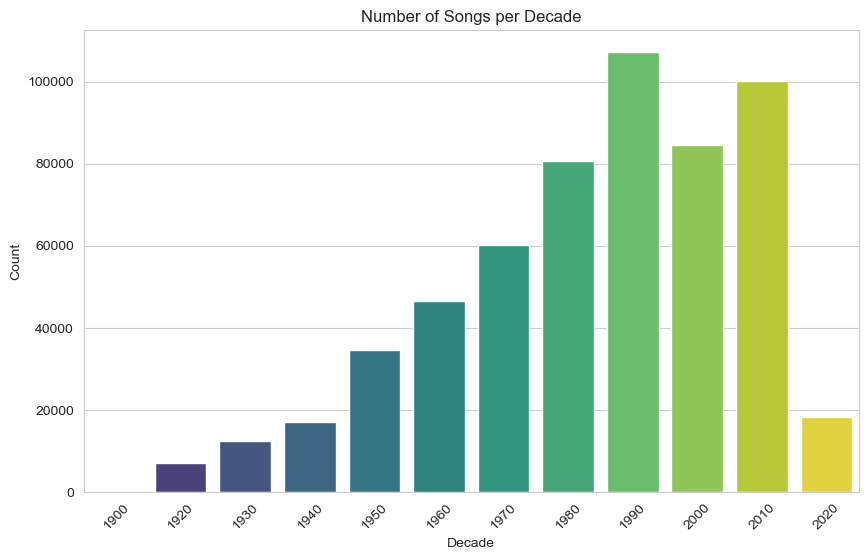

decade
1900         1
1920      7258
1930     12546
1940     17215
1950     34763
1960     46495
1970     60309
1980     80599
1990    107168
2000     84699
2010    100185
2020     18260
Name: count, dtype: int64


In [11]:
plt.figure(figsize=(10, 6))
sns.countplot(x='decade', data=tracks_clean, hue='decade', palette='viridis', legend=False)
plt.title('Number of Songs per Decade')
plt.ylabel('Count')
plt.xlabel('Decade')
plt.xticks(rotation=45)
plt.show()

print(tracks_clean['decade'].value_counts().sort_index())

#### 5.2 Feature Distributions (Density Plots)

Now, let's look at the continuous variables (like danceability, tempo, loudness). We use Kernel Density Estimation (KDE) plots, which are like smooth histograms.

What to look for:

- Bimodal distributions: If a curve has two "humps", it suggests there are two distinct groups of songs.

- Skewness: If the data is bunched up to the left or right (e.g., speechiness usually has a huge peak near 0 because most songs aren't spoken word).

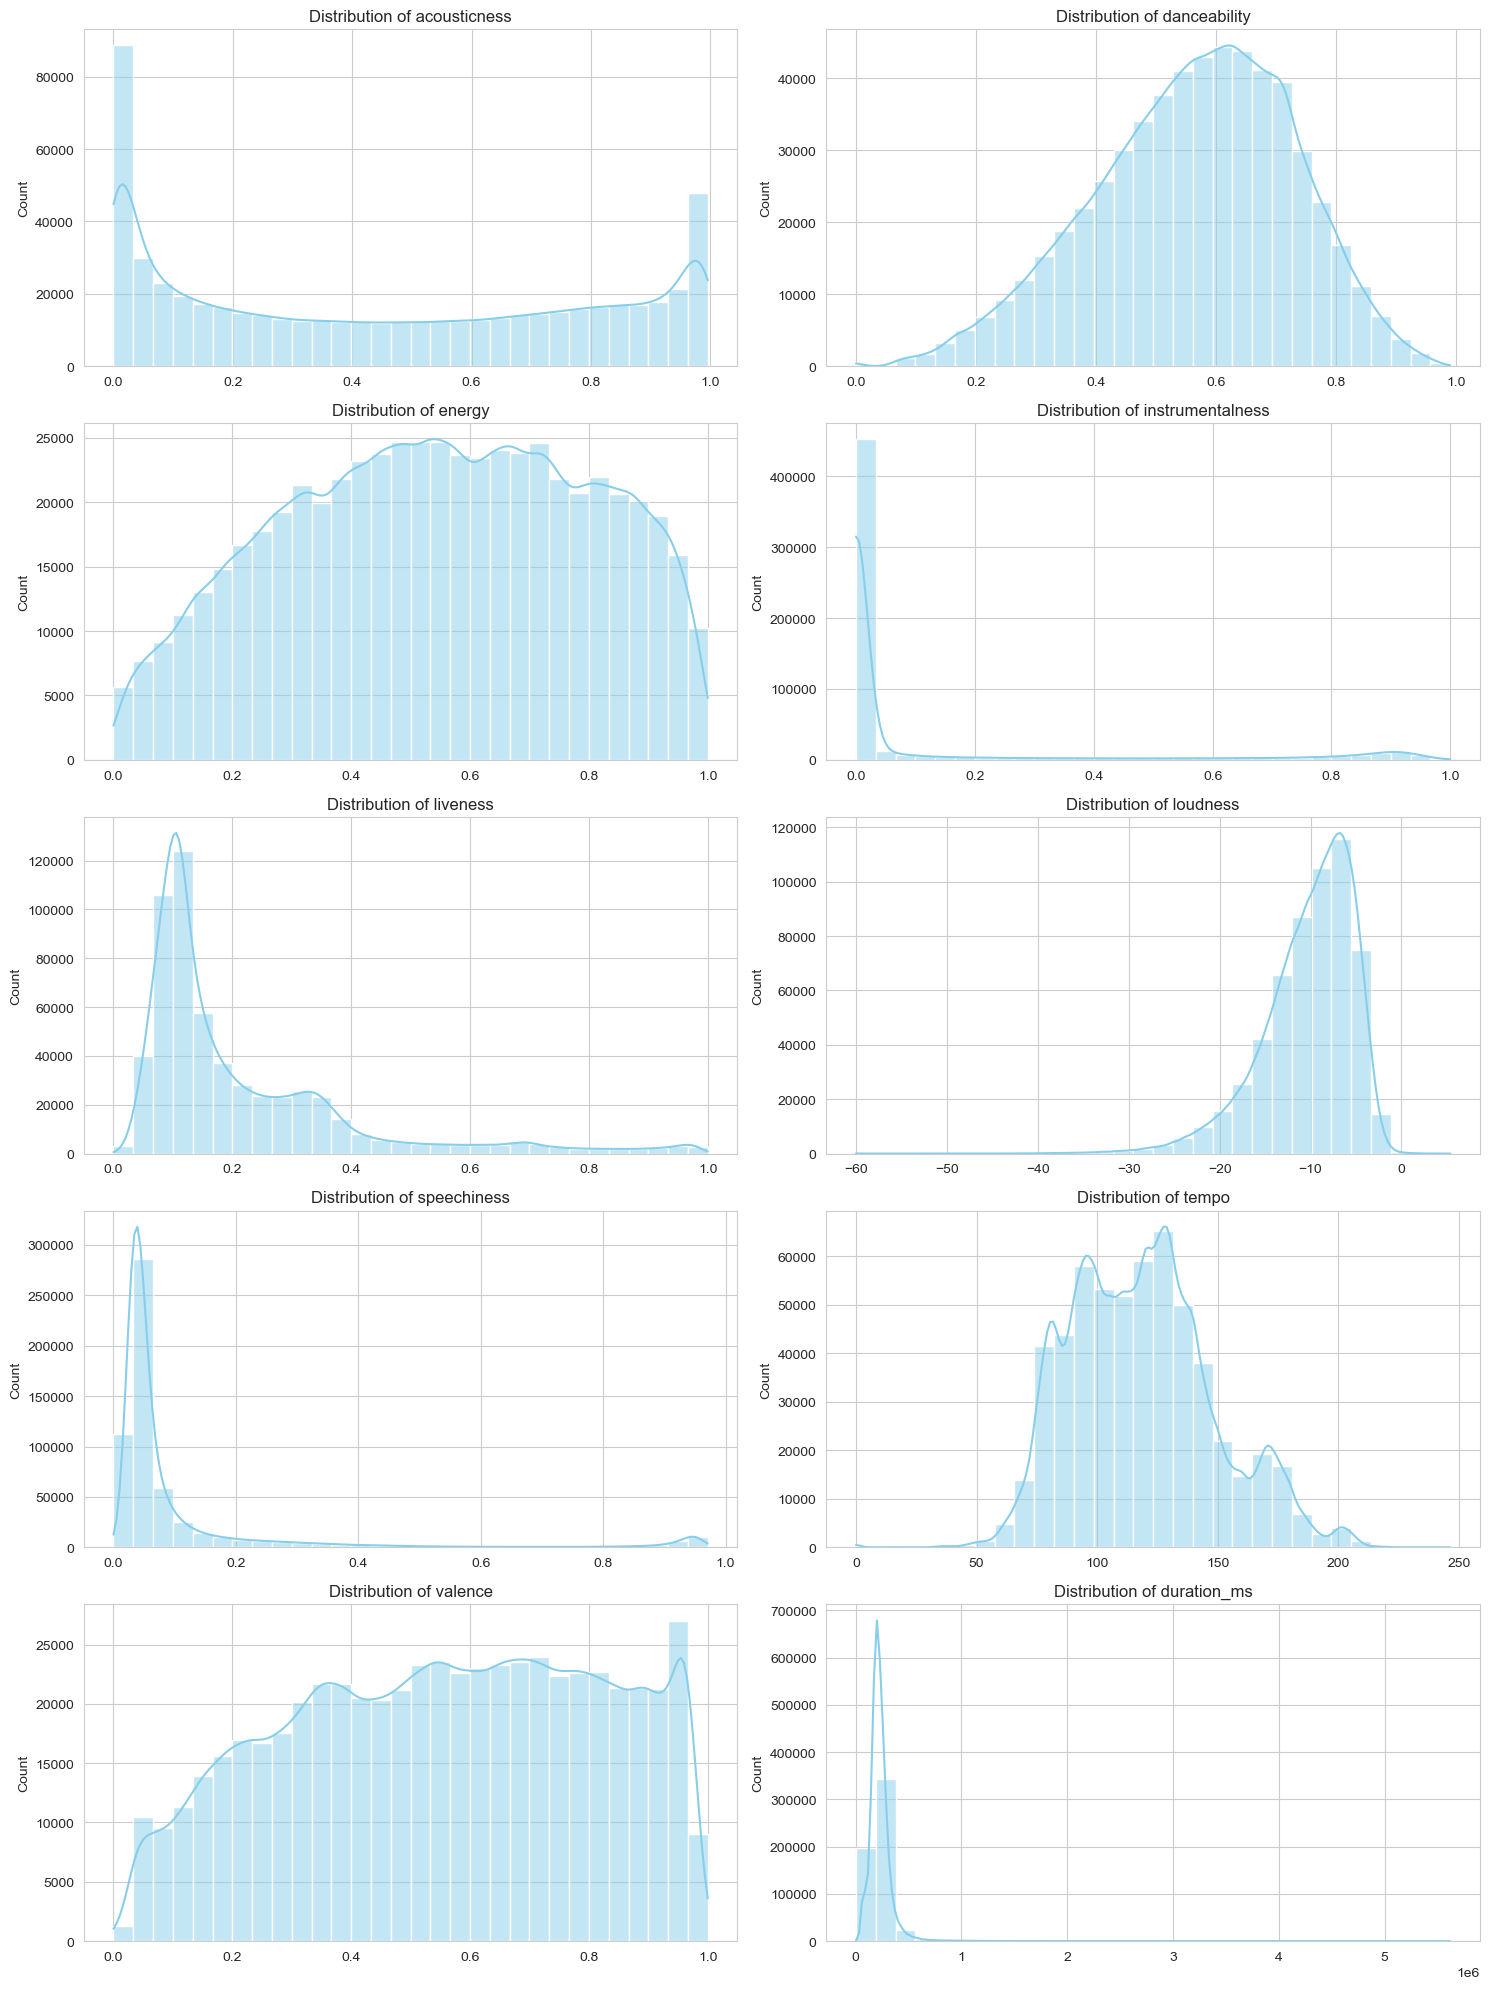

In [12]:
# Select numerical columns (excluding the target and discrete ones like key/mode)
numeric_cols = ['acousticness', 'danceability', 'energy', 'instrumentalness', 
                'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'duration_ms']

# Create a grid of subplots
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(tracks_clean[col], kde=True, ax=axes[i], color='skyblue', bins=30)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

#### 5.3 Correlation Matrix

We need to see how features relate to each other and to the target (decade).

- High Positive Correlation (closer to 1): Both variables increase together.

- High Negative Correlation (closer to -1): As one increases, the other decreases.

- Zero Correlation: No relationship.

Key thing to check: We want features that correlate with decade (the target), but we don't want features that correlate too strongly with each other (Multicollinearity), as this can confuse some models.

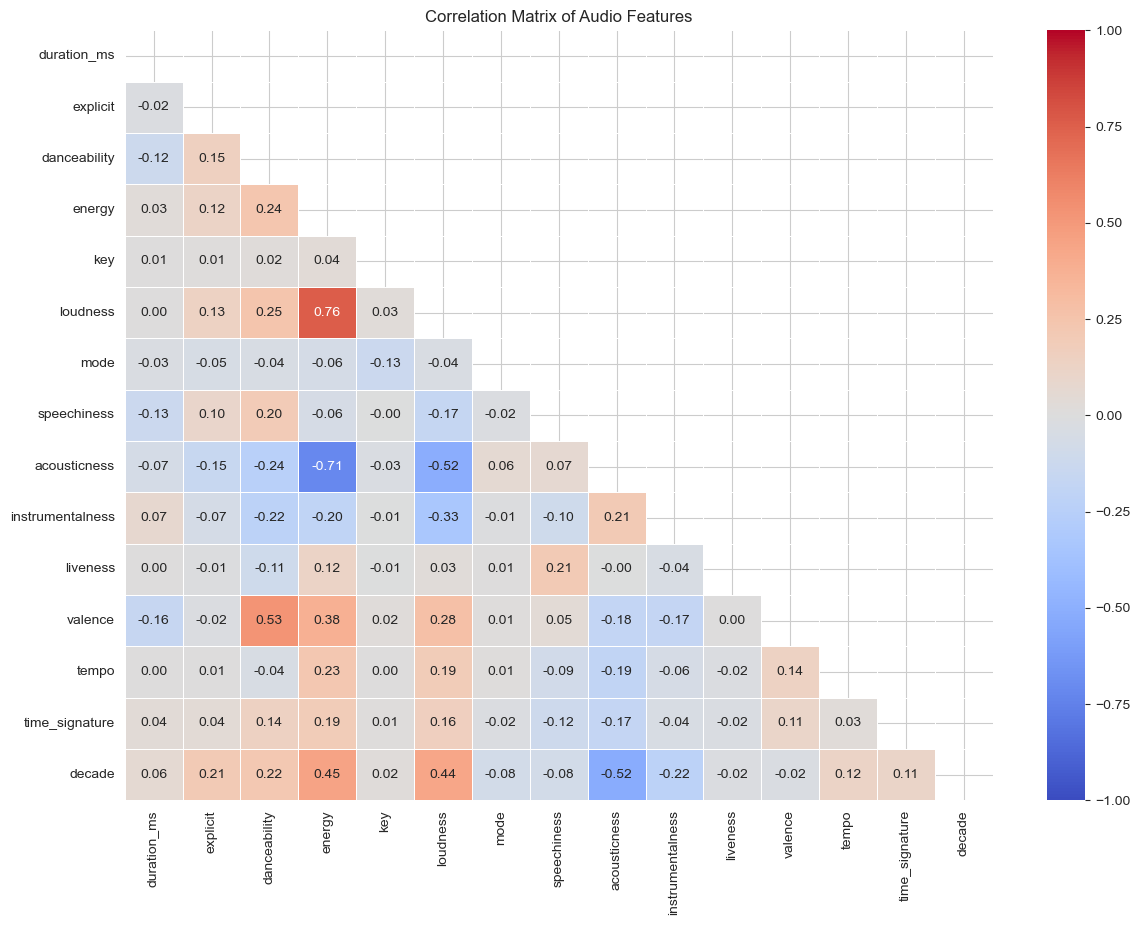

In [13]:
# Calculate correlation matrix
corr_matrix = tracks_clean.corr()

# Plot heatmap
plt.figure(figsize=(14, 10))

# Create a mask to hide the upper triangle (it's a mirror image)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            annot=True,       
            fmt=".2f",         
            cmap='coolwarm',   
            mask=mask, 
            vmin=-1, vmax=1, 
            center=0,
            linewidths=0.5)

plt.title('Correlation Matrix of Audio Features')
plt.show()

### 6. Data Pre-processing Strategy

Based on the EDA findings, we need to address three critical issues to ensure model quality:

1. Duration Outliers: We will filter out tracks that are unusually short (< 1 min) or long (> 10 min) to focus on standard musical compositions.

2. Feature Selection:

    - High Correlation: energy and loudness are strongly correlated (0.76). We will keep both for now as non-linear models (like Random Forest) can utilize subtle differences between them, but we note the redundancy.

    - Low Importance: key and mode show negligible correlation with decade. We will drop them to reduce noise.

3. Class Imbalance (Crucial): The dataset is heavily skewed towards 1990-2010. We will:

    - Filter out decades prior to 1950 (insufficient data points).

    - Apply Undersampling: We will sample an equal number of songs from each remaining decade to ensure the model doesn't just guess the majority class.

In [ ]:
# Handling Outliers: Duration between 60s and 10 min
tracks_filtered = tracks_clean[
    (tracks_clean['duration_ms'] >= 60000) & 
    (tracks_clean['duration_ms'] <= 600000)
].copy()

# Drop Noisy Features
tracks_filtered = tracks_filtered.drop(columns=['key', 'mode'])

# Balancing Strategy: 1940 to 2020
tracks_filtered = tracks_filtered[tracks_filtered['decade'] >= 1940]

# Calculate the cap based on the smallest decade
min_count = tracks_filtered['decade'].value_counts().min()
print(f"Sampling cap set to: {min_count} songs per decade")

# Group by decade and sample
balanced_df = tracks_filtered.groupby('decade').sample(n=min_count, random_state=42).reset_index(drop=True)

print(f"\nTotal Dataset Size: {balanced_df.shape[0]} songs")

Sampling cap set to: 16296 songs per decade

Total Dataset Size: 146664 songs


#### 6.1 Re-evaluating Correlation on Clean Data

Now that our data is balanced and free of outliers, we must re-check the correlations. The previous matrix was biased by the over-represented modern decades. This new matrix reflects the true relationships the model will learn.

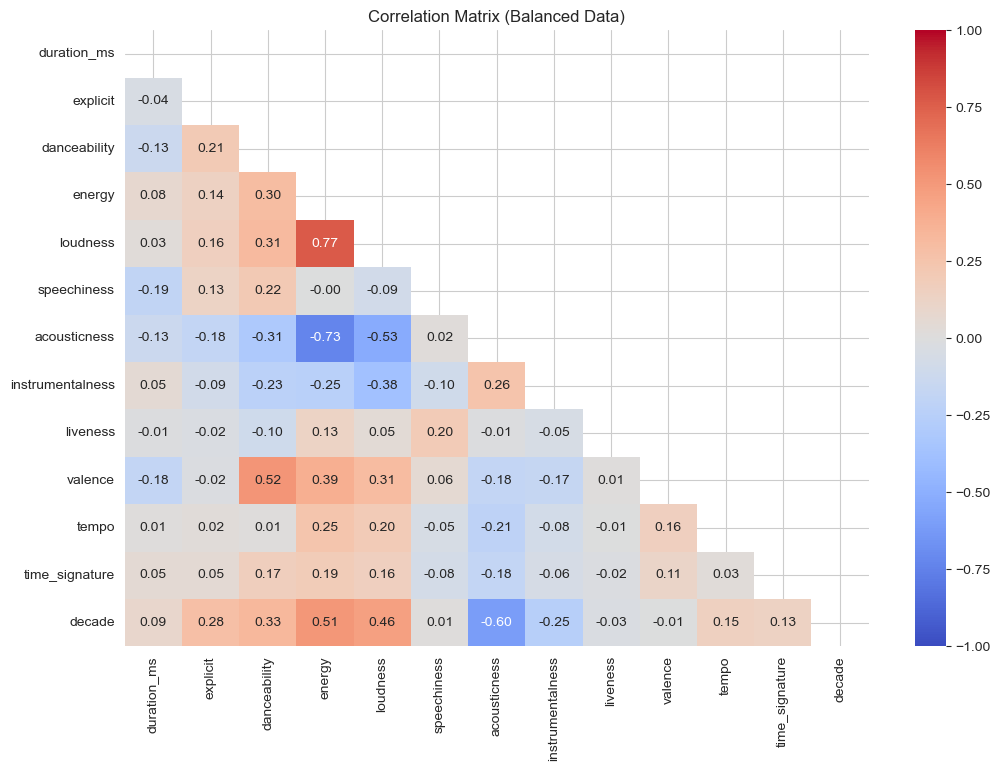

In [17]:
plt.figure(figsize=(12, 8))
corr_matrix_clean = balanced_df.corr()

mask = np.triu(np.ones_like(corr_matrix_clean, dtype=bool))
sns.heatmap(corr_matrix_clean, annot=True, fmt=".2f", cmap='coolwarm', 
            mask=mask, vmin=-1, vmax=1, center=0)
plt.title('Correlation Matrix (Balanced Data)')
plt.show()

### 7. Model Training: Random Forest Classifier

We have selected a Random Forest Classifier for this task. This algorithm is particularly well-suited for our dataset because:

1. Non-Linearity: Musical trends do not always follow a straight line over time. Random Forests capture complex, non-linear relationships.

2. Robustness: It handles potential multicollinearity (like the relationship between energy and loudness) better than linear regression models.

3. Interpretability: It allows us to extract Feature Importance, helping us understand why a song is classified as "80s" or "90s".

In [ ]:
# 1. Prepare Data
# We use the balanced dataframe. 'decade' is our target (y).
X = balanced_df.drop(columns=['decade'])
y = balanced_df['decade']

# Split: 80% Training, 20% Testing
# stratify=y is crucial here to ensure the Test set has the same proportion of decades as the Train set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
# 2. Initialize and Train
# n_estimators=100: We create 100 decision trees.
# max_depth=20: We limit the depth to prevent the model from memorizing the data (overfitting).
# n_jobs=-1: Use all available processor cores.
rf_model = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1) 
rf_model.fit(X_train, y_train)

# 3. Predict and Evaluate
y_pred = rf_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\n--- Model Accuracy ---")
print(f"Overall Accuracy: {acc:.4f} ({acc*100:.2f}%)")

Training set shape: (117331, 12)
Testing set shape: (29333, 12)
Training the Random Forest model... (This may take 1-2 minutes)
Model trained successfully!

--- Model Accuracy ---
Overall Accuracy: 0.3962 (39.62%)


We obtained an exact accuracy of 39.62%. At first glance, this might seem low, but we must consider the context:

- Random Chance: With 9 decades, a random guess would result in ~11% accuracy. Our model performs nearly 4x better than random chance.

- The "Blurry" Boundaries: Musical evolution is continuous. A rock song from 1989 sounds almost identical to one from 1991, yet they belong to different target classes (1980 vs 1990).

#### 7.1 Feature Importance Analysis

Which audio characteristics define a decade? The plot below shows which features the model relied on most to make its predictions.

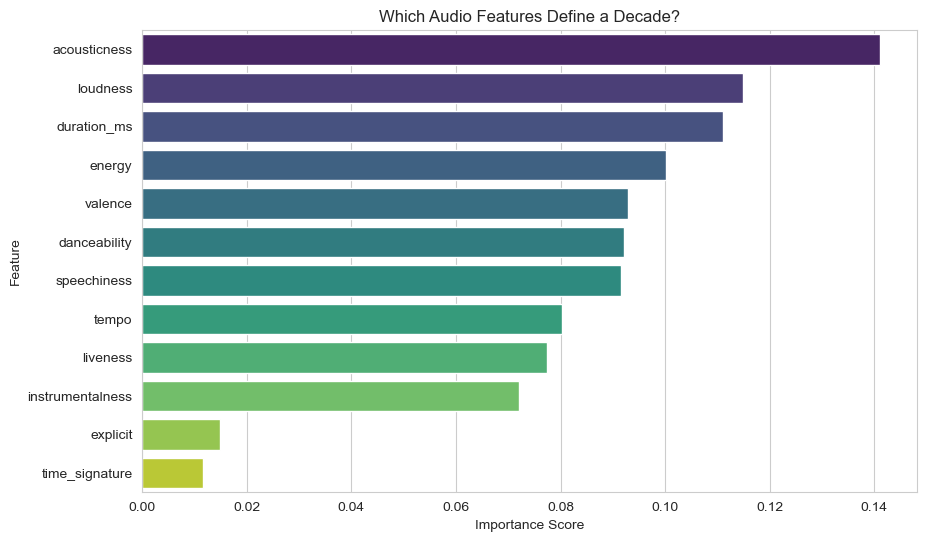

             Feature  Importance
6       acousticness    0.141183
4           loudness    0.114935
0        duration_ms    0.111095
3             energy    0.100141
9            valence    0.092993
2       danceability    0.092053
5        speechiness    0.091503
10             tempo    0.080339
8           liveness    0.077358
7   instrumentalness    0.072038
1           explicit    0.014836
11    time_signature    0.011525


In [26]:
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=feature_importances, palette='viridis', legend=False)
plt.title('Which Audio Features Define a Decade?')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

print(feature_importances)

The Random Forest model has ranked the features based on how effectively they reduce uncertainty (Gini impurity) when splitting the decades. The results are highly consistent with music history:

1. Top Predictor: acousticness: This is the strongest signal. It reflects the massive technological shift from analog recordings of acoustic instruments (dominant in the 50s/60s) to the rise of electric instruments, synthesizers, and fully digital production (dominant from the 80s to present).

2. The Loudness War: loudness: Ranked second, this validates that mastering trends are a defining characteristic of each era. The steady increase in compression and volume over the decades provides a clear linear trend for the model.

3. Song Structure: duration_ms: Interestingly, track duration is a top-3 predictor. This captures industry trends: the short radio singles of the early rock era, the extended cuts of the album-oriented 70s/80s, and the recent trend towards shorter songs optimized for streaming algorithms.

4. Low Importance Features: Variables like time_signature and explicit play a minor role. While explicit lyrics are more common today, they are not a fundamental property of the audio signal like frequency or amplitude, making them less useful for a raw audio classifier.

#### 7.2 Confusion Matrix

Accuracy gives us a single number, but the Confusion Matrix tells us the full story. It allows us to visualize:

- Correct Predictions: The diagonal line.

- Neighboring Errors: Predicting 1980s for a 1970s song (common and acceptable).

- Severe Errors: Predicting 1950s for a 2020s song (indicates anomalies).

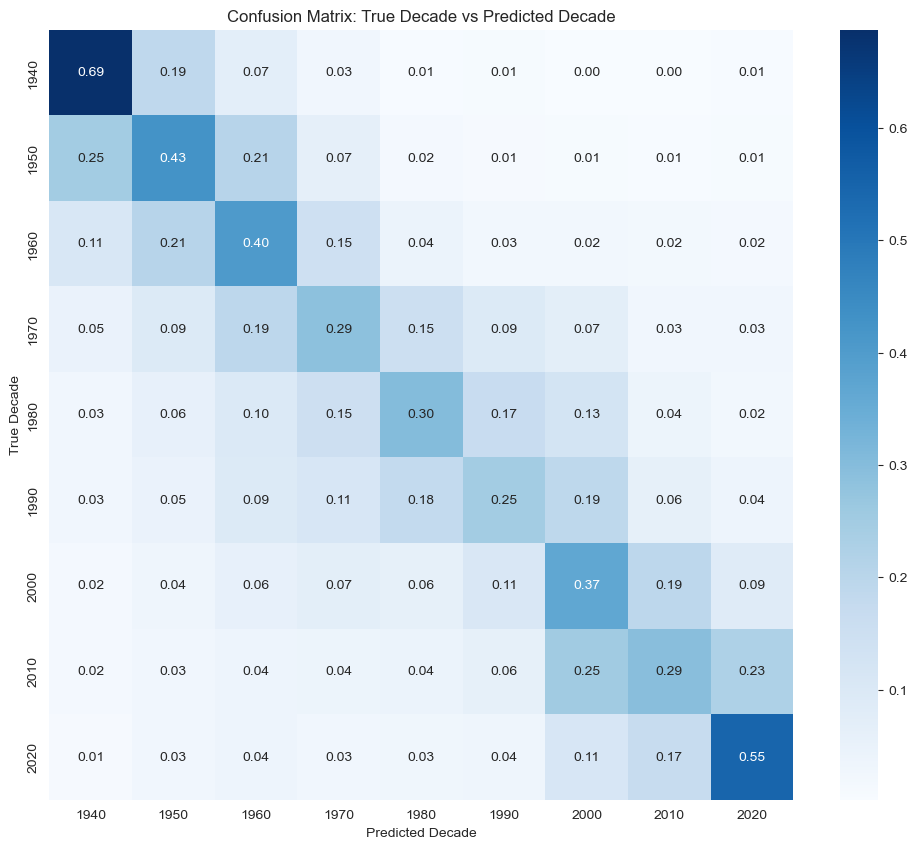

In [22]:
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred)

# Normalize the matrix to show percentages instead of raw counts
# This makes it easier to compare decades.
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Blues',
            xticklabels=sorted(balanced_df['decade'].unique()),
            yticklabels=sorted(balanced_df['decade'].unique()))

plt.title('Confusion Matrix: True Decade vs Predicted Decade')
plt.xlabel('Predicted Decade')
plt.ylabel('True Decade')
plt.show()

The confusion matrix reveals distinct patterns in how the model perceives musical evolution:

1. The "End-of-Spectrum" Effect:

    - 1940s (69% Accuracy): This is the best-predicted decade. The distinct audio characteristics of this era (low fidelity, purely acoustic instrumentation, mono recordings) make these tracks easy to isolate.

    - 2020s (55% Accuracy): Modern tracks are also highly distinct, likely due to the "Loudness War" peaking and specific modern production techniques (trap beats, hyper-compression) that didn't exist previously.

2. The "Middle Blur" (1970s - 2000s):

    - Decades like the 1990s show lower exact accuracy (~25%).

    - However, the errors are concentrated in the immediate neighboring decades. For a 1990s track, the model often guesses 1980s or 2000s. This reflects the gradual evolution of Pop and Rock genres, where boundaries are fluid rather than sharp.

3. Consistency:

    - There are virtually no "hallucinations." The model rarely mistakes a 1940s song for a 2010s song (probability < 1%). This confirms the model has learned the chronological direction of audio evolution.

#### 7.3 Evaluating "Adjacent Accuracy"

While exact accuracy gives us a strict performance metric, it fails to capture the nuance of musical evolution. Cultural changes do not happen overnight; a song released in 1989 is often stylistically identical to one released in 1990, yet a strict classifier considers this a "wrong" prediction.

To better assess the model's utility, we define a new metric: Adjacent Accuracy.

- Definition: A prediction is considered "correct" if it falls within the exact decade OR the immediately neighboring decades (± 10 years).

- Goal: This measures if the model correctly identifies the broader "musical era" (e.g., placing a 70s song in the 60s, 70s, or 80s), effectively filtering out severe errors (like confusing 1950s with 2020s).

In [27]:
def get_adjacent_accuracy(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    diff = np.abs(y_true - y_pred)
    
    matches = (diff <= 10)
    return matches.mean()

adj_acc = get_adjacent_accuracy(y_test, y_pred)

print(f"Exact Accuracy:     {acc*100:.2f}%")
print(f"Adjacent Accuracy:  {adj_acc*100:.2f}%")

Exact Accuracy:     39.62%
Adjacent Accuracy:  72.74%


### 8. Project Conclusions

In this analysis, we leveraged a dataset of over 140,000 songs (1940–2020) to determine if raw audio features alone could predict the release decade of a track.

Key Findings:

- Audio is a Historical Marker: We achieved an Adjacent Accuracy of ~73%. This proves that roughly 3 out of 4 times, the model can correctly pinpoint the musical era of a song purely based on its engineering and composition metrics, without needing any lyrics or metadata.

- The Evolution of Sound: Feature importance analysis revealed that acousticness and loudness are the strongest predictors of time. This mirrors the historical shift from analog, acoustic recordings in the mid-20th century to the highly compressed, digital, and synthesized production of the modern era (The "Loudness War").

- Logical Errors: The Confusion Matrix showed that errors are almost exclusively concentrated in neighboring decades (e.g., confusing 1990s with 2000s). The model rarely makes "severe" mistakes (e.g., confusing 1950s with 2020s), confirming it has learned the chronological direction of musical evolution.

*Final Thought*

While lyrics are often considered the "soul" of a song, this project demonstrates that the "body" — the technical audio signal — carries a distinct timestamp. As music production technology evolves, it leaves a measurable fingerprint that Machine Learning can successfully decode.